In [103]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

Loading names

In [ ]:

n = pd.read_csv('processed_names.csv',names=['names'],header = 0)
names = n['names'].tolist()

# creating char to int and int to char convertion
stoi = {} ; itos = {}
for i,j in enumerate(sorted(set('.'+''.join(names)))):
    stoi[j] = i
    itos[i] = j

Creating the pairs of characters

In [ ]:

def pair_generator(names,num_char):
    X = [] # 'num' numbers of pairs in the character
    Y = [] # char after the pairs ===> "Label"
    for name in names:
        tri_set = [0]*num_char
        name = '.'+name+'.'
        for char1,char2 in zip(name,name[1:]):
            tri_set = tri_set[1:]+[stoi[char1]]
            X.append(tri_set)
            Y.append(stoi[char2])
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

num_pairs = 3
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))
X_train,Y_train = pair_generator(names[:n1],num_pairs)
X_dev,Y_dev = pair_generator(names[n1:n2],num_pairs)
X_test,Y_test = pair_generator(names[n2:],num_pairs)

Creating the layers in the nueral network

In [ ]:

n1 = 10
n2 = 100
num_charecters = 27
batch_size = 32
g = torch.Generator().manual_seed(1)

class nn:
    class Linear:
        def __init__(self,in_features,out_features, bias = True):
            self.weight = torch.randn(out_features,in_features)#/in_features**0.5 #use when batchnorm is not in layer
            self.bias = torch.zeros(out_features) if bias == True else None
        def __call__(self,x):
            if self.bias != None:
                self.out = x@self.weight.T + self.bias
            else:
                self.out = x@self.weight.T 
            return self.out
        def parameters(self):
            return [self.weight] + ([] if self.bias == None else [self.bias])
    class BatchNorm1d:
        def __init__(self,num_features,eps = 0.00001,momentum = 0.1,track_running_status = True,bias = True):
            self.track_running_status = track_running_status
            self.momentum = momentum
            self.weight = torch.ones(num_features).float()
            self.bias = torch.zeros(num_features).float() if bias == True else None
            self._running_mean = torch.zeros(num_features).float()
            self._running_var = torch.ones(num_features).float()
            self.eps = eps
            self.training = True
        def __call__(self,x):
            if self.training:
                x_mean = x.mean(0,keepdim = True)
                x_var = x.var(0,keepdim = True)
                if self.track_running_status :
                    with torch.no_grad():
                        self._running_var = self._running_var*(1-self.momentum) + self.momentum*x_var
                        self._running_mean = self._running_mean*(1-self.momentum) + self.momentum*x_mean
            else:
                x_mean = self._running_mean
                x_var = self._running_var

            self.out = (x - x_mean)/(x_var+self.eps).sqrt() * self.weight + (self.bias if self.bias != None else 0)
            return self.out
        def parameters(self):
            return [self.weight] + ([] if self.bias == None else [self.bias])
    class tanh:
        def __call__(self,x):
            self.out = x.tanh()
            return self.out
layers = [
    nn.Linear(in_features=num_charecters,out_features=n1,bias=False),
    nn.Linear(in_features=num_pairs*n1,out_features=n2,bias=True),      nn.BatchNorm1d(n2,momentum=0.01),  nn.tanh(),
    nn.Linear(in_features=n2,out_features=n2,bias=True),                nn.BatchNorm1d(n2,momentum=0.01),  nn.tanh(),
    nn.Linear(in_features=n2,out_features=n2,bias=True),                nn.BatchNorm1d(n2,momentum=0.01),  nn.tanh(),
    nn.Linear(in_features=n2,out_features=n2,bias=True),                nn.BatchNorm1d(n2,momentum=0.01),  nn.tanh(),
    nn.Linear(in_features=n2,out_features=n2,bias=True),                nn.BatchNorm1d(n2,momentum=0.01),  nn.tanh(),
    nn.Linear(in_features=n2,out_features=num_charecters,bias=True),    nn.BatchNorm1d(num_charecters,momentum=0.01)
]
for layer in layers[1:-1]:
    if isinstance(layer, nn.Linear):
        layer.weight *= 1#5/3
layers[-1].weight *= 0.01 # Explicitly scale the last layer

parameters = [p for layer in layers for p in (layer.parameters() if isinstance(layer,(nn.Linear,nn.BatchNorm1d)) else [])]
for p in parameters:
    p.requires_grad_(True)

Training the network

In [ ]:

lossi = []
p_mean = []
update_ratio = []
for _ in range(12000):
    rate = 0.5 if _ < 4000 else (0.1 if _<8000 else 0.02)
    batch_index = torch.randint(0,X_train.shape[0],(batch_size,),generator=g)
    X = X_train[batch_index]
    Y = Y_train[batch_index]

    # forward
    enc = F.one_hot(X,27).float()
    x = layers[0](enc).view(batch_size,-1)
    for i,layer in enumerate(layers[1:]):
        x = layer(x)
    loss = F.cross_entropy(x,Y)        
    

    #backward
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -rate*p.grad
    update_ratio.append([(rate*p.grad.std()/p.data.std()) for p in parameters])
    # Svaing paramters
    lossi.append(loss.item())

    if _ % 1000 == 0: 
        print(loss.item())

3.292506217956543
2.1995465755462646
1.7563124895095825
1.960256576538086
1.725003719329834
1.8723657131195068
1.9526188373565674
2.130446195602417
1.3394910097122192
1.9033721685409546
1.768904209136963
1.2281335592269897


Optimising plots

12000


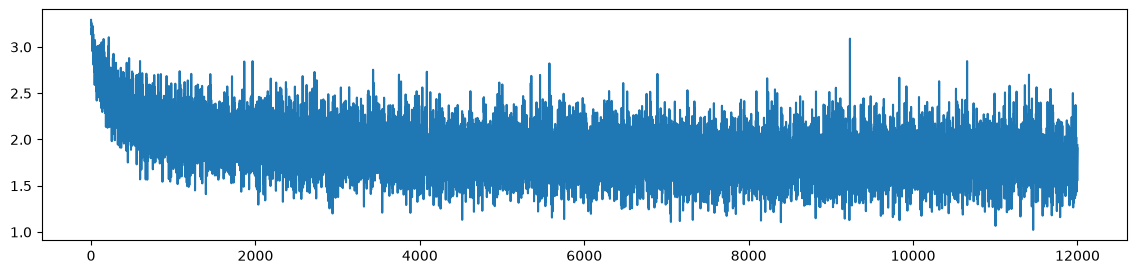

In [112]:
print(len(lossi))
plt.figure(figsize=(14,3));
plt.plot(lossi)

layer3 : mean = 0.0160 | std = 0.6558 | saturation above 0.97 = 0.08 
layer6 : mean = 0.0090 | std = 0.6678 | saturation above 0.97 = 0.07 
layer9 : mean = 0.0265 | std = 0.6760 | saturation above 0.97 = 0.08 
layer12 : mean = 0.0464 | std = 0.6762 | saturation above 0.97 = 0.07 
layer15 : mean = -0.0187 | std = 0.6791 | saturation above 0.97 = 0.06 


Text(0.5, 1.0, 'tanh() out value Gradient Distribution')

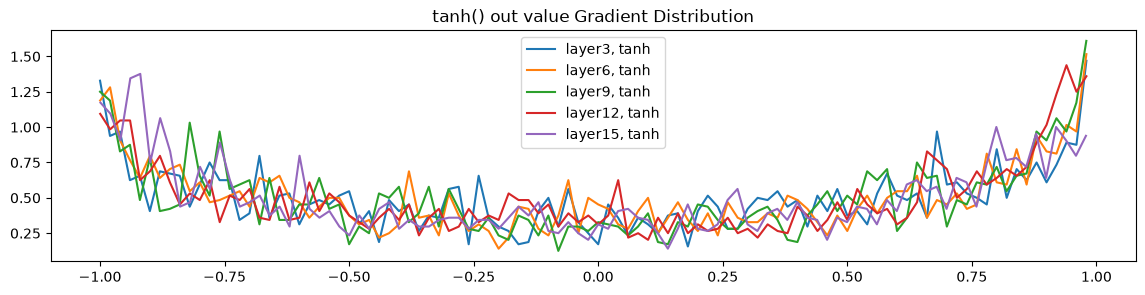

In [113]:
legends = []
plt.figure(figsize=(14,3));
for _,layer in enumerate(layers):
    if isinstance(layer,nn.tanh):
        hy,hx = torch.histogram(layer.out,density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        saturation = (layer.out.abs() > 0.97).float().mean()
        print(f'layer{_} : mean = {layer.out.mean():0.4f} | std = {layer.out.std():0.4f} | saturation above 0.97 = {saturation:0.2f} ')
        legends.append(f'layer{_}, {layer.__class__.__name__}')
plt.legend(legends)
plt.title('tanh() out value Gradient Distribution')

layer3 : mean = 2.328306384496992e-12, std = 0.008203827776014805
layer6 : mean = -1.9790604918745736e-11, std = 0.007122489158064127
layer9 : mean = -5.122274132629556e-11, std = 0.006618769373744726
layer12 : mean = -3.725290215195187e-11, std = 0.006756174843758345
layer15 : mean = 2.7939676613963904e-11, std = 0.006658890750259161


Text(0.5, 1.0, 'tanh out Gradient Distribution')

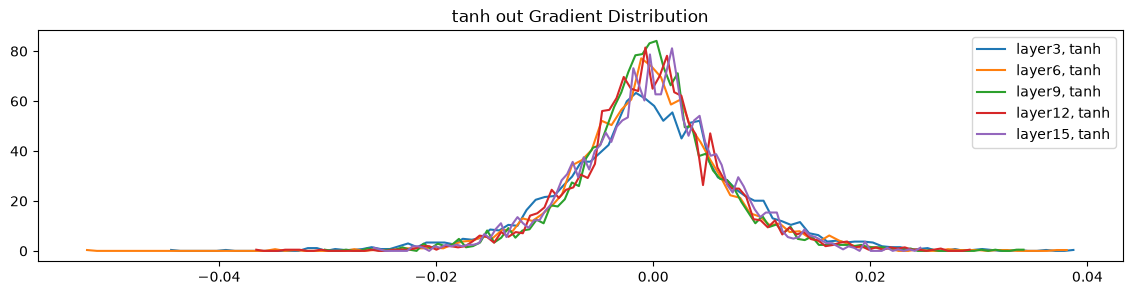

In [114]:
legends = []
plt.figure(figsize=(14,3));
for i,layer in enumerate(layers):
    if isinstance(layer,nn.tanh):
        hy,hx = torch.histogram(layer.out.grad,density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        print(f'layer{i} : mean = {layer.out.grad.mean()}, std = {layer.out.grad.std()}')
        legends.append(f'layer{i}, {layer.__class__.__name__}')
plt.legend(legends)
plt.title('tanh out Gradient Distribution')

weight (10, 27)   | mean +0.000000 | std 1.870316e-02 | grad:data ratio 1.638242e-02
weight (100, 30)  | mean +0.000133 | std 6.115742e-03 | grad:data ratio 6.153665e-03
weight (100, 100) | mean +0.000056 | std 2.675509e-03 | grad:data ratio 2.666087e-03
weight (100, 100) | mean -0.000018 | std 2.530103e-03 | grad:data ratio 2.512142e-03
weight (100, 100) | mean +0.000000 | std 2.401835e-03 | grad:data ratio 2.407597e-03
weight (100, 100) | mean +0.000028 | std 2.289339e-03 | grad:data ratio 2.296068e-03
weight (27, 100)  | mean -0.000082 | std 4.179418e-03 | grad:data ratio 4.196864e-03


Text(0.5, 1.0, 'Weights Gradient Distribution')

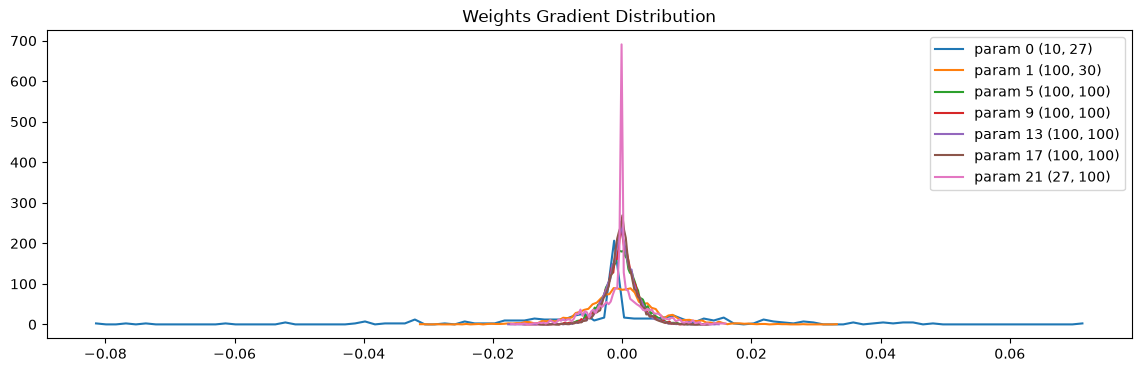

In [115]:
plt.figure(figsize=(14, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2: # Only 2D weight tensors
        t = p.grad
        ratio = t.std() / p.std()
        print(f'weight {str(tuple(p.shape)):10s} | mean {t.mean():+f} | std {t.std():e} | grad:data ratio {ratio:e}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'param {i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weights Gradient Distribution')

C:\Users\akash\AppData\Local\Temp\ipykernel_8048\581742276.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plt.plot([ torch.tensor(update_ratio[j][i]).log10().item() for j in range(len(update_ratio)) ])


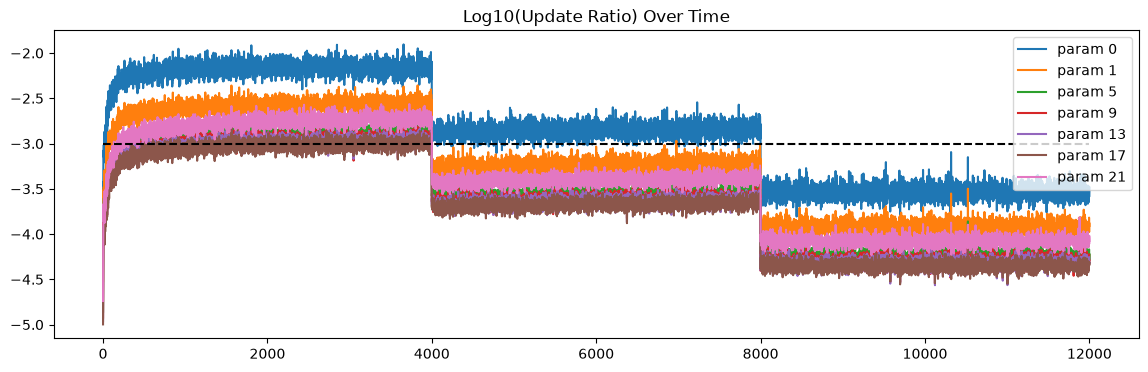

In [116]:
# 3. Update Ratio Over Training Steps (Target is ~ -3.0 on log10 scale)
plt.figure(figsize=(14, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ torch.tensor(update_ratio[j][i]).log10().item() for j in range(len(update_ratio)) ])
        legends.append(f'param {i}')
plt.plot([0, len(update_ratio)], [-3, -3], 'k--') # Target line at 1e-3
plt.legend(legends)
plt.title('Log10(Update Ratio) Over Time')
plt.show()

Output names

In [117]:
g = torch.Generator().manual_seed(1)
n_names  = 10

for layer in layers:
    if isinstance(layer,nn.BatchNorm1d):
        layer.training = False
                
with torch.no_grad():
    for _ in range(n_names):
        X = torch.tensor([0,0,0])
        name = ''
        while True:
            enc = F.one_hot(X,27).float()
            x = layers[0](enc).view(1,-1)
            for layer in layers[1:]:
                x = layer(x)
            prob = F.softmax(x,dim=1)
            out  = torch.multinomial(prob,1,replacement=True,generator=g)
            if out == 0:
                break
            X = torch.cat([X[1:],out.view(-1)],dim=0)
            name += itos[out.item()]
        print(name)

aneesh
lema
subhan
roseph
deva
smarya
rese
charika
madha
sijo
